In [51]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

In [52]:
df=pd.read_csv(r"C:\Users\vv\Downloads\New folder\weather\india_2000_2024_daily_weather.csv")
df

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,13.3,58
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,14.8,326
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,23.8,309
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,18.7,311
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,20.2,322
...,...,...,...,...,...,...,...,...,...,...,...,...
91315,Lucknow,2024-12-27,25.6,13.9,25.9,13.7,0.0,0.0,3,10.1,22.3,88
91316,Lucknow,2024-12-28,22.4,15.9,21.7,15.7,0.5,0.5,51,16.5,39.6,108
91317,Lucknow,2024-12-29,22.8,13.5,22.9,13.9,0.3,0.3,51,12.3,28.1,273
91318,Lucknow,2024-12-30,20.8,12.4,20.1,12.0,0.0,0.0,1,11.5,26.6,278


In [53]:
df.columns = df.columns.str.strip().str.lower()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [54]:
# Select one city
city_name = "Delhi"   # change as needed
df = df[df["city"] == city_name]
df

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,13.3,58
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,14.8,326
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,23.8,309
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,18.7,311
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,20.2,322
...,...,...,...,...,...,...,...,...,...,...,...,...
9127,Delhi,2024-12-27,16.8,14.1,16.6,13.6,31.9,31.9,63,10.9,29.2,64
9128,Delhi,2024-12-28,18.2,12.1,18.8,11.7,2.9,2.9,61,7.6,17.6,340
9129,Delhi,2024-12-29,18.4,10.7,17.7,9.6,0.0,0.0,3,8.9,23.4,305
9130,Delhi,2024-12-30,18.3,9.5,17.9,8.1,0.0,0.0,3,9.2,24.1,284


In [55]:
df = df.dropna()

In [67]:
# Keep target column
data = df["temperature_2m_max"].values.reshape(-1,1)

In [68]:
# Scale
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [70]:
# Create sequences
def create_dataset(dataset, time_step=30):
    X, y = [], []

    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step,0])
        y.append(dataset[i+time_step,0])

    return np.array(X), np.array(y)

time_step = 30

X, y = create_dataset(data_scaled, time_step)


In [71]:
# Reshape for GRU
X = X.reshape(X.shape[0], X.shape[1], 1)

In [72]:
# Train/Test Split
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [74]:
# Build GRU
model = Sequential([GRU(50, input_shape=(time_step,1)),Dense(1)])

In [75]:
model.compile(optimizer="adam",loss="mse")

In [76]:
# Train
model.fit(X_train,y_train,epochs=20,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/20
228/228 [==============================] - 12s 32ms/step - loss: 0.0235 - val_loss: 0.0035
Epoch 2/20
228/228 [==============================] - 5s 22ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 3/20
228/228 [==============================] - 5s 23ms/step - loss: 0.0024 - val_loss: 0.0025
Epoch 4/20
228/228 [==============================] - 5s 20ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 5/20
228/228 [==============================] - 5s 21ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 6/20
228/228 [==============================] - 5s 22ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 7/20
228/228 [==============================] - 5s 21ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 8/20
228/228 [==============================] - 6s 27ms/step - loss: 0.0020 - val_loss: 0.0023
Epoch 9/20
228/228 [==============================] - 6s 26ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 10/20
228/228 [==============================] - 6s 25ms/step - loss: 0.0019 - val_l

In [77]:
# Predict
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

57/57 [==============================] - 1s 8ms/step


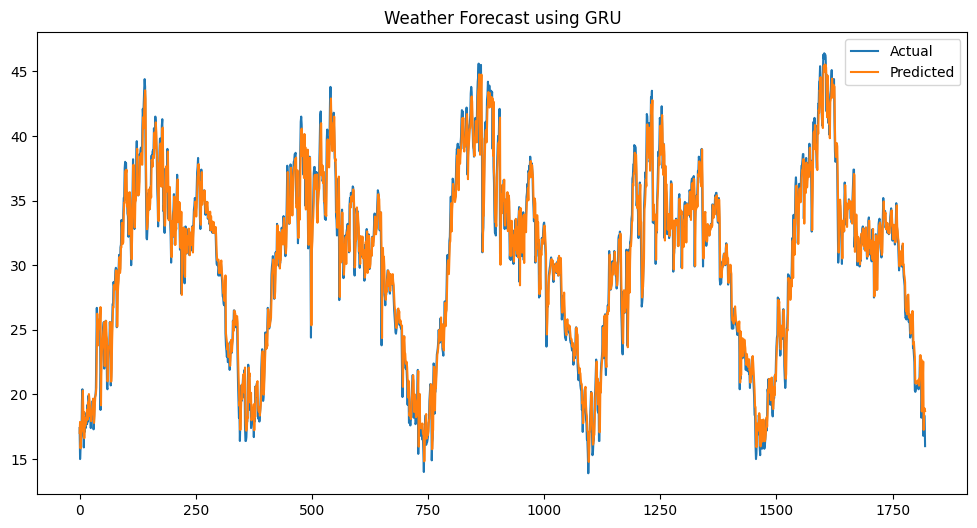

In [78]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Weather Forecast using GRU")
plt.show()

In [79]:
last_seq = data_scaled[-30:]

future = []

for _ in range(7):

    x = last_seq.reshape(1,30,1)

    next_temp = model.predict(x, verbose=0)

    future.append(next_temp[0,0])

    last_seq = np.vstack([last_seq[1:], next_temp])

future = scaler.inverse_transform(np.array(future).reshape(-1,1))

print("Next 7 Day Forecast")
print(future)

Next 7 Day Forecast
[[16.681204]
 [17.2418  ]
 [17.665337]
 [17.968493]
 [18.219542]
 [18.453262]
 [18.681435]]
